In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [2]:
# 수집 데이터 관련
DATA_DIRS = ['../Data/Images/Kiwi','../Data/Images/Pear', '../Data/Images/Strawberry', '../Data/Images/Watermelon']
DATA_LABEL = ['Kiwi', 'Pear', 'Strawberry', 'Watermelon']

In [3]:
data_list = []
for target, label in zip(DATA_DIRS, DATA_LABEL):
    filelist = os.listdir(target)

    for filename in filelist:
        img = cv2.imread(f'{target}/{filename}', cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f'읽기 실패: {filename}')
            continue

        row = img.flatten().tolist() + [label]
        data_list.append(row)

print(f'data_list : {len(data_list)}')

data_list : 1925


In [4]:
columns = [f'pixel{i}' for i in range(100*100)] + ['label']
df = pd.DataFrame(data_list, columns=columns)
df.to_csv('fruit_data2.csv', index=False)

In [11]:
df = pd.read_csv('fruit_data2.csv')
display(df)
x = df.iloc[:,:-1].values / 255.0
y = df['label'].values
print(f'정규화 후 : \n{x[:3, :]}')

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel9991,pixel9992,pixel9993,pixel9994,pixel9995,pixel9996,pixel9997,pixel9998,pixel9999,label
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Kiwi
1,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Kiwi
2,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Kiwi
3,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Kiwi
4,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Kiwi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Watermelon
1921,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Watermelon
1922,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Watermelon
1923,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,Watermelon


정규화 후 : 
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


In [6]:
X_train, X_test, y_train, y_test = train_test_split( x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print(f'train : {X_train.shape}, test : {X_test.shape}')

train : (1540, 10000), test : (385, 10000)


In [ ]:
# # => 교차 검증 기반 학습 [1] KFold
kfold = KFold(n_splits=5) # 기본값
scoreDF = pd.DataFrame(columns=["K_NO", "model", "train_score", "valid_score"])

for no, (train_idx, valid_idx) in enumerate(kfold.split(X_train), start=1):
    # 학습용, 검증용 데이터 셋 구성
    train_x, train_y = X_train[train_idx], y_train[train_idx]
    valid_x, valid_y = X_train[valid_idx], y_train[valid_idx]

    # 학습
    kModel= KNeighborsClassifier()
    svcModel= SVC(kernel='linear')
    
    kModel.fit(train_x, train_y)
    svcModel.fit(train_x, train_y)

    scoreDF.loc[f"KNN_{no}"] = [no, "KNN", kModel.score(train_x, train_y), kModel.score(valid_x, valid_y)]
    scoreDF.loc[f"SVC_{no}"] = [no, "SVC", svcModel.score(train_x, train_y), svcModel.score(valid_x, valid_y)]

scoreDF.describe()

,K_NO,train_score,valid_score
count,10.000000,10.000000,10.000000
mean,3.000000,0.999107,0.998701
std,1.490712,0.001044,0.001677
min,1.000000,0.997565,0.996753
25%,2.000000,0.998377,0.996753
50%,3.000000,0.999594,1.000000
75%,4.000000,1.000000,1.000000
max,5.000000,1.000000,1.000000


In [8]:
# # => 교차 검증 기반 학습 [2] StratifiedKFold
skfold = StratifiedKFold(n_splits=5) # 기본값
scoreDF2 = pd.DataFrame(columns=["K_NO", "model", "train_score", "valid_score"])

for no, (train_idx, valid_idx) in enumerate(skfold.split(X_train, y_train), start=1):
    # 학습용, 검증용 데이터 셋 구성
    train_x, train_y = X_train[train_idx], y_train[train_idx]
    valid_x, valid_y = X_train[valid_idx], y_train[valid_idx]

    # 학습
    kModel= KNeighborsClassifier()
    svcModel= SVC(kernel='linear')
    
    kModel.fit(train_x, train_y)
    svcModel.fit(train_x, train_y)

    scoreDF2.loc[f"KNN_{no}"] = [no, "KNN", kModel.score(train_x, train_y), kModel.score(valid_x, valid_y)]
    scoreDF2.loc[f"SVC_{no}"] = [no, "SVC", svcModel.score(train_x, train_y), svcModel.score(valid_x, valid_y)]

scoreDF2.describe()

,K_NO,train_score,valid_score
count,10.000000,10.000000,10.000000
mean,3.000000,0.999107,0.998701
std,1.490712,0.000972,0.002270
min,1.000000,0.997565,0.993506
25%,2.000000,0.998377,0.997565
50%,3.000000,0.999188,1.000000
75%,4.000000,1.000000,1.000000
max,5.000000,1.000000,1.000000


In [9]:
# 통계기반 분석
resultDF = scoreDF[scoreDF.columns[1:]].groupby('model').agg(['min','max','mean','std'])
display(resultDF)

resultDF2 = scoreDF2[scoreDF2.columns[1:]].groupby('model').agg(['min','max','mean','std'])
display(resultDF2)


train_score                               valid_score                 \
              min       max      mean       std         min  max      mean   
model                                                                        
KNN      0.997565  0.999188  0.998214  0.000679    0.996753  1.0  0.997403   
SVC      1.000000  1.000000  1.000000  0.000000    1.000000  1.0  1.000000   

                 
            std  
model            
KNN    0.001452  
SVC    0.000000

train_score                               valid_score                 \
              min       max      mean       std         min  max      mean   
model                                                                        
KNN      0.997565  0.998377  0.998214  0.000363    0.993506  1.0  0.997403   
SVC      1.000000  1.000000  1.000000  0.000000    1.000000  1.0  1.000000   

                 
            std  
model            
KNN    0.002716  
SVC    0.000000

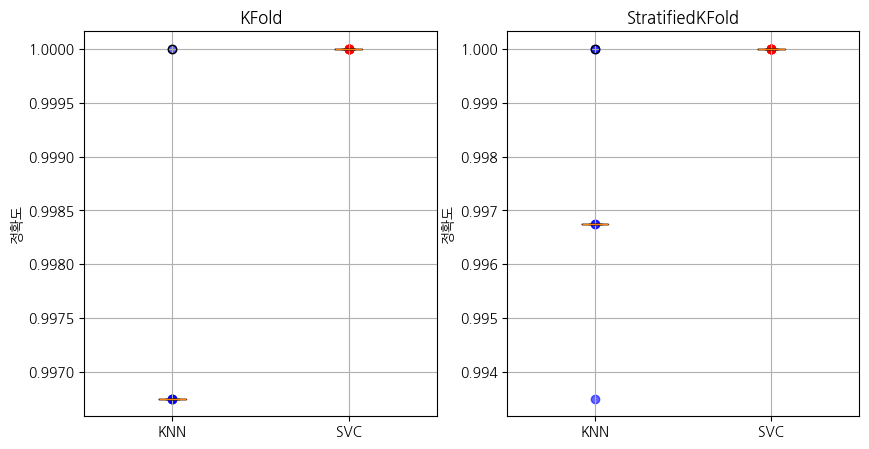

In [10]:
# 모델별 검증(valid) 점수 분포 표출
knn_scores = scoreDF[scoreDF['model'] == 'KNN']['valid_score'].values
svc_scores = scoreDF[scoreDF['model'] == 'SVC']['valid_score'].values

knn_scores2 = scoreDF2[scoreDF['model'] == 'KNN']['valid_score'].values
svc_scores2 = scoreDF2[scoreDF['model'] == 'SVC']['valid_score'].values

datas = [[knn_scores, svc_scores], [knn_scores2, svc_scores2]]
titles = ['KFold', 'StratifiedKFold']

# 시각화 : 모델별 K-Fold 검증 점수 분포 비교
fig, axes = plt.subplots(1,2, figsize=(10,5))

for ax, (knn, svc), title in zip(axes, datas, titles):
    ax.boxplot([knn_scores, svc_scores], tick_labels=['KNN', 'SVC'])
    ax.scatter([1] * len(knn), knn, color='blue', alpha=0.6)
    ax.scatter([2] * len(svc), svc, color='red', alpha=0.9)
    ax.set_ylabel('정확도')
    ax.set_title(title)
    ax.grid()
plt.show()